In [1]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

preprocessor = load("artifacts/preprocessor.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = load("artifacts/splits_raw.joblib")

X_train_final = preprocessor.transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)


"""# Define parameter grid for efficient tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10]
}

# Initialize and train with GridSearchCV
gb_clf = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(gb_clf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_final, y_train)

# Get best model
best_model = grid_search.best_estimator_

# Evaluate on validation set
val_score = best_model.score(X_val_final, y_val)
test_score = best_model.score(X_test_final, y_test)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Validation score: {val_score:.4f}")
print(f"Test score: {test_score:.4f}")"""

NameError: name 'load' is not defined

In [ ]:
def train_gradient_boosting_model(X_train_final, X_val_final, X_test_final, y_train, y_val, y_test):
    """
    Train and evaluate a Gradient Boosting classifier with GridSearchCV.
    
    Returns:
        tuple: (best_model, best_params, val_score, test_score)
    """
    param_grid = {
        'n_estimators': [18],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [5, 10]
    }
    
    gb_clf = GradientBoostingClassifier(random_state=42)
    grid_search = GridSearchCV(gb_clf, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(X_train_final, y_train)
    
    best_model = grid_search.best_estimator_
    val_score = best_model.score(X_val_final, y_val)
    train_score = best_model.score(X_train_final, y_train)
    test_score = best_model.score(X_test_final, y_test)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Validation score: {val_score:.4f}")
    print(f"Training score: {train_score:.4f}")
    print(f"Test score: {test_score:.4f}")
    
    return best_model, grid_search.best_params_, val_score, train_score, test_score

# Call the function
best_model, best_params, val_score, train_score, test_score = train_gradient_boosting_model(
    X_train_final, X_val_final, X_test_final, y_train, y_val, y_test
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 18}
Validation score: 0.8949
Test score: 0.8941


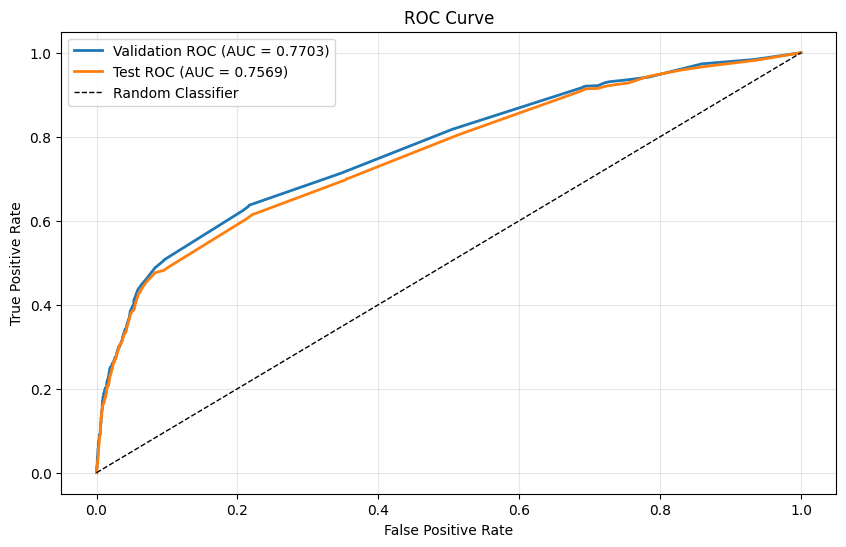

Validation - ROC AUC: 0.7703, F1 Score: 0.2704
Test - ROC AUC: 0.7569, F1 Score: 0.2539


In [ ]:
from sklearn.metrics import roc_curve, auc, f1_score, roc_auc_score

import matplotlib.pyplot as plt

def evaluate_model_roc_auc_f1(best_model,X_train_final,X_val_final, X_test_final, y_val, y_test, y_train):
    """
    Evaluate model using ROC curve, AUC, and F1 score on validation and test sets.
    
    Parameters:
        best_model: trained classifier
        X_train_final: training features
        X_val_final: validation features
        X_test_final: test features
        y_val: validation labels
        y_test: test labels
    """
    # Get prediction probabilities
    y_train_proba = best_model.predict_proba(X_train_final)[:, 1]
    y_val_proba = best_model.predict_proba(X_val_final)[:, 1]
    y_test_proba = best_model.predict_proba(X_test_final)[:, 1]
    
    # Get predictions
    y_train_pred = best_model.predict(X_train_final)
    y_val_pred = best_model.predict(X_val_final)
    y_test_pred = best_model.predict(X_test_final)
    
    # Calculate metrics
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    val_roc_auc = roc_auc_score(y_val, y_val_proba)
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Plot ROC curves
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
    
    plt.figure(figsize=(10, 6))
    plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_roc_auc:.4f})', linewidth=2)
    plt.plot(fpr_val, tpr_val, label=f'Validation ROC (AUC = {val_roc_auc:.4f})', linewidth=2)
    plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    # Print metrics
    print(f"Training - ROC AUC: {train_roc_auc:.4f}, F1 Score: {train_f1:.4f}")
    print(f"Validation - ROC AUC: {val_roc_auc:.4f}, F1 Score: {val_f1:.4f}")
    print(f"Test - ROC AUC: {test_roc_auc:.4f}, F1 Score: {test_f1:.4f}")
    
    return train_roc_auc, val_roc_auc, test_roc_auc, train_f1, val_f1, test_f1

# Call the function
train_roc_auc, val_roc_auc, test_roc_auc, train_f1, val_f1, test_f1 = evaluate_model_roc_auc_f1(
    best_model,X_train_final,X_val_final, X_test_final, y_val, y_test, y_train
)

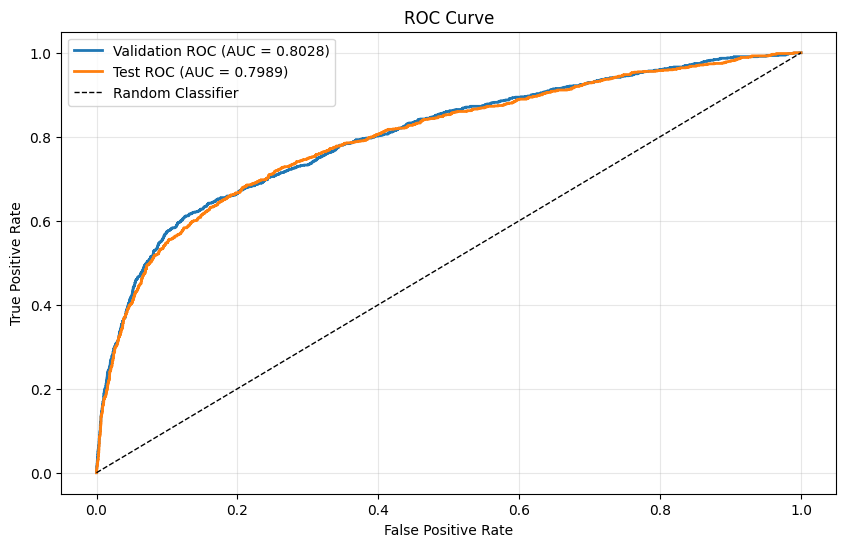

Validation - ROC AUC: 0.8028, F1 Score: 0.4199
Test - ROC AUC: 0.7989, F1 Score: 0.4184


In [ ]:
def train_gradient_boosting_model_weighted(X_train_final, X_val_final, X_test_final, y_train, y_val, y_test,weights ):
    """
    Train and evaluate a Gradient Boosting classifier with GridSearchCV.
    
    Returns:
        weighted_model: trained classifier
    """
    
    gb_clf = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=10,
        random_state=42
    )
    gb_clf.fit(X_train_final, y_train, sample_weight=weights)
    
    
    return gb_clf

weights = np.where(y_train == 1, 8.0, 1.0)  # Example class weights, adjust as needed

# Call the function
weighted_model = train_gradient_boosting_model_weighted(
    X_train_final, X_val_final, X_test_final, y_train, y_val, y_test, weights
)


# Call the function
w_train_roc_auc, w_val_roc_auc, w_test_roc_auc, w_train_f1, w_val_f1, w_test_f1 = evaluate_model_roc_auc_f1(
    weighted_model,X_train_final,X_val_final, X_test_final, y_val, y_test, y_train
)

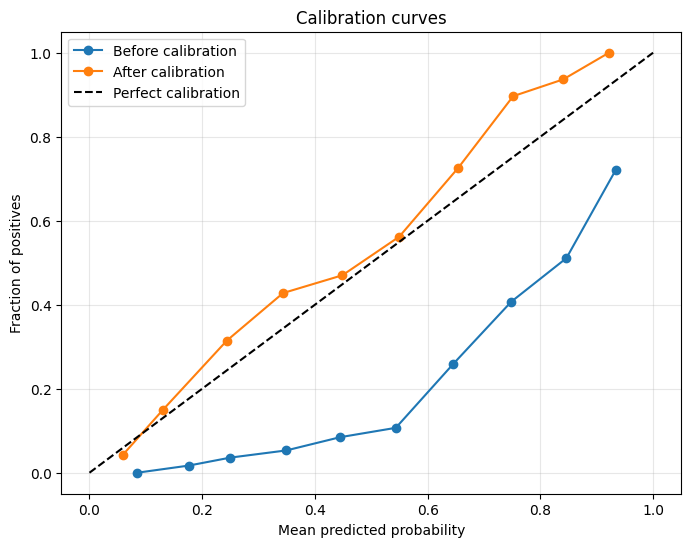

In [62]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt
import numpy as np

def prob_calibrator(model, X_cal, y_cal, n_bins=10):
    """
    Calibrate probabilities and plot calibration curves (before & after).
    """

    # ---------- BEFORE calibration ----------
    y_proba = model.predict_proba(X_cal)[:, 1]
    prob_true, prob_pred = calibration_curve(y_cal, y_proba, n_bins=n_bins)

    # ---------- Calibration ----------
    calibrated_model = CalibratedClassifierCV(
        model,
        method="sigmoid",
        cv=5
    )
    calibrated_model.fit(X_cal, y_cal)

    # ---------- AFTER calibration ----------
    y_proba_cal = calibrated_model.predict_proba(X_cal)[:, 1]
    prob_true_cal, prob_pred_cal = calibration_curve(
        y_cal, y_proba_cal, n_bins=n_bins
    )

    # ---------- Plot ----------
    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, "o-", label="Before calibration")
    plt.plot(prob_pred_cal, prob_true_cal, "o-", label="After calibration")
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return calibrated_model


# Use with your weighted_model
calibrated_weighted_model = prob_calibrator(weighted_model, X_val_final, y_val, n_bins=10)




In [ ]:
# Expected calibration error (ECE) calculation
def expected_calibration_error(y_true, y_proba, n_bins=10):
    """
    Calculate Expected Calibration Error (ECE).
    
    Parameters:
        y_true: true binary labels
        y_proba: predicted probabilities for the positive class
        n_bins: number of bins to use for calibration curve
    
    Returns:
        ece: Expected Calibration Error
    """
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)
    
    # Calculate ECE
    ece = np.sum(np.abs(prob_true - prob_pred) * np.histogram(y_proba, bins=n_bins)[0] / len(y_true))
    
    return ece


In [65]:
# Choose threshold on validation and evaluate once on test
y_val_proba = calibrated_weighted_model.predict_proba(X_val_final)[:, 1]

thresholds = np.linspace(0.01, 0.5, 50)
f1_scores = [f1_score(y_val, (y_val_proba > t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold)

# Evaluate once on test
y_test_proba = calibrated_weighted_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_proba > best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_f1 = f1_score(y_test, y_test_pred)

print("Test ROC-AUC:", test_roc_auc)
print("Test F1:", test_f1)

Best threshold: 0.21000000000000002
Test ROC-AUC: 0.7840153974903321
Test F1: 0.46502463054187193


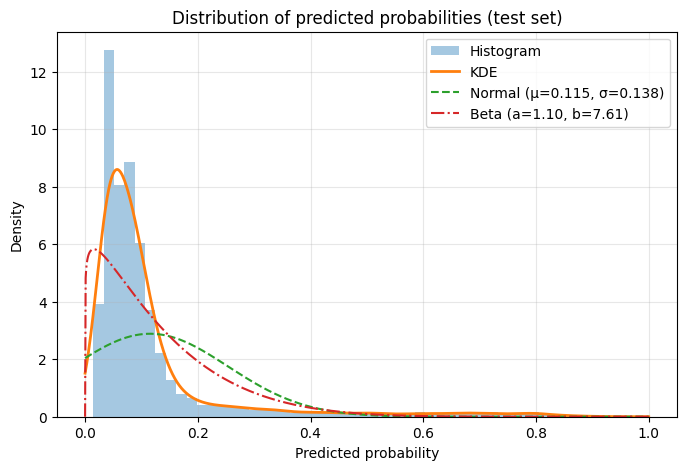

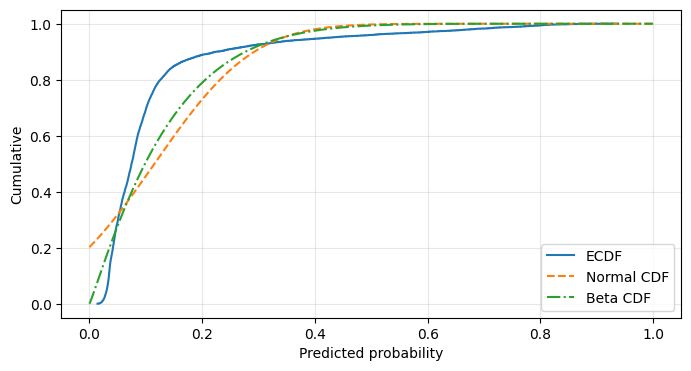

Normal fit: mu=0.1153, sigma=0.1382, KS=0.2718, p=0.0000
Beta fit: a=1.1042, b=7.6077, loc=0.0000, scale=1.0000, KS=0.2062, p=0.0000


In [66]:
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt

probas = y_test_proba  # use existing variable

# Histogram + KDE + fitted PDFs (Normal & Beta)
x = np.linspace(0, 1, 1000)
kde = stats.gaussian_kde(probas)
norm_mu, norm_std = stats.norm.fit(probas)
# fit Beta on [0,1]
a, b, loc, scale = stats.beta.fit(probas, floc=0, fscale=1)

plt.figure(figsize=(8, 5))
plt.hist(probas, bins=50, density=True, alpha=0.4, label="Histogram")
plt.plot(x, kde(x), label="KDE", linewidth=2)
plt.plot(x, stats.norm.pdf(x, norm_mu, norm_std), '--', label=f"Normal (μ={norm_mu:.3f}, σ={norm_std:.3f})")
plt.plot(x, stats.beta.pdf(x, a, b, loc=loc, scale=scale), '-.', label=f"Beta (a={a:.2f}, b={b:.2f})")
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Distribution of predicted probabilities (test set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ECDF and fitted CDFs
sorted_p = np.sort(probas)
ecdf_y = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
plt.figure(figsize=(8, 4))
plt.step(sorted_p, ecdf_y, where='post', label="ECDF")
plt.plot(x, stats.norm.cdf(x, norm_mu, norm_std), '--', label="Normal CDF")
plt.plot(x, stats.beta.cdf(x, a, b, loc=loc, scale=scale), '-.', label="Beta CDF")
plt.xlabel("Predicted probability")
plt.ylabel("Cumulative")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Goodness-of-fit (Kolmogorov-Smirnov)
ks_norm = stats.kstest(probas, 'norm', args=(norm_mu, norm_std))
ks_beta = stats.kstest(probas, 'beta', args=(a, b, loc, scale))
print(f"Normal fit: mu={norm_mu:.4f}, sigma={norm_std:.4f}, KS={ks_norm.statistic:.4f}, p={ks_norm.pvalue:.4f}")
print(f"Beta fit: a={a:.4f}, b={b:.4f}, loc={loc:.4f}, scale={scale:.4f}, KS={ks_beta.statistic:.4f}, p={ks_beta.pvalue:.4f}")